# Week 21 - Markov Chains

Markov Chains are stochastic (random) processes used to model sequences of possible events where the probability of each possible event is determined only by the previous event. We sometimes refer to this property as 'memorylessness', because the probabilities of events are independent of the history of events, and depend only on the most recent event (or current state).

There are two types of Markov Chains: 
- Discrete Time Markoc Chains (chain moves in discrete time steps)
- Continuous Time Markov Chains (chain moves in continuous time steps)

A Markov Chain is defined by three things:
- State Space: a discrete space representing all possibilities
- Transition Matrix: a matrix of probabilities of all possible transitions
- Initial State: the starting point of the system
  
Let use a common wind energy example to define a Markov Chain. When we wish to carry out repairs, maintenance, checks or install upgrades we rely on certain weather conditions to do so. In reality, these conditions depend on many variables such as wind speed, rain and when offshore factors like wave height and current, however for simplicity we will just focus on two simple possibilities: good and bad weather.

#### Defining the State Space
At any given time the weather is either good or bad. This defines our **state space**. In this case we have a two-state space because there are exactly two possibilities.
Now we have defined all possible states we need to decide all possible **events** or **transitions**. Here we have four possible transitions:
- $T_{g,b}$: weather changes from good to bad
- $T_{g,g}$: weather stays good
- $T_{b,b}$: weather stays bad
- $T_{b,g}$: weather changes from bad to good
  
each have some associated probability
- $P_{g,b}$
- $P_{g,g}$
- $P_{b,b}$
- $P_{b,g}$

respectively.

We can draw the system with the state space and transition probabilities as below.
    
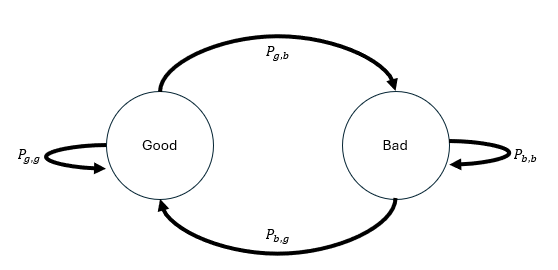

#### Defining the Transition Matrix
It is important to note that whilst a two-state system can have at most 4 possible transitions, they may have less than this if for example, there is no possibility of exiting a state. In this system, that wouldn't really make sense but let's imagine we're modelling cooking an egg. We can eventually move from the uncooked state to the cooked state, but we wouldn't be able to move back. In this scenario we would only have three possibilities (cooked can only remain cooked, uncooked can remain uncooked or become cooked). In general, if we have $n$ possible states, we can have between $n$ (as each state must have a possible transition) and $n^2$ possible transitions. Transitions which are not possible may be omitted from the system diagram, but they will still be defined within the transition matrix (as 0), which defines the probability of every state transitioning to every other state, and will always be square. Non-zero transition matrix probabilities are a little trickier as we need to understand (or best estimate) the chance of these transitions.
Let's define our probabilities as 
$$
T = \begin{bmatrix}
P_{g,g} & P_{g,b}\\
P_{b,g} & P_{b,b}
\end{bmatrix}= \begin{bmatrix}
0.25 & 0.75\\
0.5 & 0.5
\end{bmatrix}
$$

This transition matrix tells us that if the weather is good now, there is a 25% chance it will be good in the next time step, and a 75% chance it will be bad in the next time step. If the weather is bad now, there is an equal chance of it being good or bad in the next time step.


#### Defining the Initial State
We define the initial state vector as the probability of each possible state. This state is essentially the long term probability of being in each state, and we calculate it using our transition probabilities. Let's look at the probability of having good weather at the next time step, $P(g)$. There are two ways to reach this. Either it is good now, and remains good. Or it is bad now and transitions to good. The sum of these probabilities is

$$ P(g) = P(g) \cdot P_{g,g} + P(b) \cdot P_{b,g}.$$

Since there are only two possible states, $P(b) = 1 - P(g)$ and this simplifies to

$$\begin{align} P(g) &= P(g) \cdot P_{g,g} + (1 - P(g)) P_{b,g} \\
& = P(g) P_{g,g} + P_{b,g} - P(g) P_{b,g}\cdot \end{align}, $$

which may be rewritten as 
$$\begin{align} 
P(g)(1-P_{g,g}+P_{b,g}) &= P_{b,g}\\
\Rightarrow P(g) &= \frac{P_{b,g}}{1+P_{b,g}-P_{g,g}}. \end{align}$$

Since we know these probabilties we can substitute them in and calculate
$$ P(g) = \frac{0.5}{1+0.5-0.25} = \frac{0.5}{1.25} = 0.4. $$

Finally this defines our initial state vector as 
$$ \pi_0 = \begin{bmatrix} 0.4 \\ 0.6 \end{bmatrix}. $$

In [2]:
import numpy as np

p_initial = np.random.rand(1)[0] # generate a random value between 0 and 1
state = 'g' if p_initial < 0.4 else 'r' # use the random value to generate the initial state with probability 0.4 for good and 0.6 for bad
all_states = [state] # create a list to store states

# Carry out the Monte Carlo Simulation by running the following 1000 times...
for i in range(10000):
    p = np.random.rand(1)[0] # Generate a random value between 0 and 1
    if state == 'g': # if the initial state is good...
        state = 'g' if p < 0.25 else 'b' #...remain good with a probability of 0.25, and transition to bad with a probability of 0.75
    else: # otherwise (if the initial state is bad)...
        state = 'g' if p < 0.5 else 'b' # ... transition to good with a probability of 0.5 or remain bad with a probability of 0.5
    all_states.append(state) # add current state to the state history

#### Exercise 1
Explicitly define the matrices $\pi_0$ and $T$. Rewrite the above code to draw the probabilities from these variables.

In [3]:
pi_0 = np.array([0.4,0.6])
T = np.array([[0.25, 0.75], [0.5, 0.5]])

p_initial = np.random.rand(1)[0]
state = 'g' if p_initial < pi_0[0] else 'b'
all_states = [state]

for i in range(10000):
    p = np.random.rand(1)[0]
    if state == 'g':
        state = 'g' if p < T[0,0] else 'b'
    else:
        state = 'g' if p < T[1,0] else 'b'
    all_states.append(state) 

#### Estimating Transition Matrices
Now let's imagine we have not started off with the key information of $\pi_0$ and $T$, and instead wish to build our model based on observed data. Let's reverse engineer the process by using our simulated data to estimate the six probabilities of interest:
$P(g)$, $P(b)$, $P_{g,g}$, $P_{g,b}$, $P_{b,b}$, and $P_{b,g}$.
In many cases we may use information available and mathematical reasoning to obtain the true values for our probabilities. An easy first step in at least reducing the problem where we have a two-state space is understanding that if there are only two possible transitions from a state, and that all possible steps must have combined probabilitity of 1, that the probability of one possible step is 1 minus the probability of the other possible step.

I.e.
$$
\begin{bmatrix}
P_{g,g} & P_{g,b}\\
P_{b,g} & P_{b,b}
\end{bmatrix}= \begin{bmatrix}
P_{g,g} & 1-P_{g,g}\\
1-P_{b,b} & P_{b,b}
\end{bmatrix}
$$

we now only have two probabilities to consider for $T$.

Similarly, we can see that $\pi_0$ reduces to
$$\pi_0 = \begin{bmatrix} P(g) \\ P(b) \end{bmatrix} = \begin{bmatrix} P(g) \\ 1-P(g) \end{bmatrix} $$

Our problem now reduces to finding $P(g)$, $P_{g,g}$, and $P_{b,b}$.

We may estimate these three probabilities in a number of ways - the simplest is to take an empirical measurement from data. Let's first estimate $P(g)$ as the proportion of time spent in this state.

In [42]:
P_g = all_states.count('g')/10000
print(f' P(g) = {P_g}')

 P(g) = 0.3996


Calculating the transition probabilities is also relatively straightforward, we calculate the proportion of transitions given starting at that state. To help organise our data, it can be helpful to restructure it as a dataframe.

In [7]:
import pandas as pd

# define a dataframe of all states alongside their next consecutive state
markov_chain = pd.DataFrame({'current_state':all_states, 'next_state': all_states[1:]+['null']})
markov_chain = markov_chain[:-1]

good_states = markov_chain[markov_chain['current_state']=='g'] # extract all good states
p_gg = len(good_states[good_states['next_state']=='g'])/len(good_states) # calculate proportion of good states whose next state is also good
p_gb = 1-p_gg

print(f'P(g->g) = {np.round(p_gg,2)}')
print(f'P(g->b) = {np.round(p_gb,2)}')

P(g->g) = 0.25
P(g->b) = 0.75


#### Excercise 2 
Using the same method calculate $P_{bb}$ and $P_{bg}$.

In [9]:
bad_states = markov_chain[markov_chain['current_state']=='b']
p_bb = len(bad_states[bad_states['next_state']=='b'])/len(bad_states)
p_bg = 1-p_bb

print(f'P(b->b) = {np.round(p_bb,2)}')
print(f'P(b->g) = {np.round(p_bg,2)}')

P(b->b) = 0.5
P(b->g) = 0.5


In this tutorial we have covered how to define a Markov Chain and a Markov Chain Monte Carlo simulation mathematically and in code, and how to estimate a model from observed data for a two-state space. For larger state spaces or extension work, please feel to reach out to me for more resources and information.